# The Bowman-2018 pipeline: single-day analysis

This notebook performs the single-day parts of the analysis pipeline that matches the Bowman+2018 results, using the python `edges-collab` stack. This loads in a full day of data, flags out bad integrations, flags RFI, and averages all retained LSTs.

In [1]:
from multiprocessing import Pool

In [2]:
p = Pool(1)

In [3]:
p.map_async?

In [4]:
datadir: str = "/data5/edges/data/2014_February_Boolardy/mro/low/"
alan_output_dir: str = "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/"
cachedir: str = "./cache"

year: int = 2016
day: int = 261

do_aux_filter: bool = True
aux_filter_params: dict = {
    'minima': {},
    'maxima': {
        'adcmax': 0.35
    }
}

lst_min: float = 6.0
lst_max: float = 18.0
use_alan_coordinates: bool = True

do_power_percent_filter: bool = True
power_percent_params = {
    'min_threshold': 0.7,
    'max_threshold': 3
}

do_peak_orbcomm_filter: bool = True
peak_orbcomm_params = {
    'threshold': 40.0
}

do_maxfm_filter: bool = True
maxfm_filter_params = {
    'threshold': 200.0
}

do_rmsf_filter: bool = True
rmsf_filter_params = {
    'freq_range': [60., 80.],
    'threshold': 200.0
}

lstbin_params = {    
    "binsize": 12.0,
    'first_edge': 6.0,
    'max_edge': 18.0,
    'use_model_residuals': False,
    'in_gha': True,
}

gauss_smooth_params = {
    "size": 8,
    'decimate_at': 0,
    'maintain_flags': 1,
    'flag_threshold': 0.25,
    'use_nsamples': True,
}

do_balun_connector_loss: bool = True
do_antenna_loss: bool = False
do_ground_loss: bool = False
do_beam_correction: bool = False  # should be True to match B18      

first_freqcut_min: float = 40.0  # MHz
first_freqcut_max: float = 100.0  # MHz

inject_flags: bool = True
calfile: str = "/data4/smurray/edges/alans-pipeline/edges-cal-outputs/specal.txt"
#calfile: str = "/data4/smurray/edges/alans-pipeline/scripts/H2Case-fittpfix//specal.txt"

In [5]:
# Parameters
calfile = "/data4/smurray/edges/alans-pipeline/edges-cal-outputs/specal.txt"
inject_flags = True
first_freqcut_max = 100.0
first_freqcut_min = 40.0
do_beam_correction = False
do_ground_loss = False
do_antenna_loss = False
do_balun_connector_loss = True
do_rmsf_filter = True
do_maxfm_filter = True
do_peak_orbcomm_filter = True
do_power_percent_filter = True
use_alan_coordinates = True
lst_max = 18.0
lst_min = 6.0
do_aux_filter = True
day = 263
year = 2016
cachedir = "./cache"
alan_output_dir = "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/"
datadir = "/data5/edges/data/2014_February_Boolardy/mro/low/"
papermill_input_path = "/data4/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/notebooks/single-day.ipynb"


## Imports and Versions

In [6]:
from pathlib import Path
from importlib.metadata import version
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
import h5py
import hickle

from pygsdata import plots, GSData, GSFlag
from pygsdata.select import select_freqs, select_lsts, lst_selector

from read_acq.gsdata import read_acq_to_gsdata, fast_lst_setter

from edges_cal import Calibrator
from edges_cal.alanmode import read_specal_as_calibrator, read_spec_txt
from edges_cal import modelling as mdl
from edges_cal.tools import dicke_calibration, FrequencyRange

from edges_analysis.calibration.calibrate import approximate_temperature, apply_beam_correction, apply_loss_correction, apply_noise_wave_calibration
from edges_analysis.calibration.s11 import AntennaS11
from edges_analysis.calibration.loss import low2_balun_connector_loss
from edges_analysis.const import KNOWN_TELESCOPES
from edges_analysis.averaging.freqbin import gauss_smooth
from edges_analysis.averaging.lstbin import lst_bin
from edges_analysis.filters import filters
from edges_analysis.datamodel import add_model


In [7]:
print("Versions: ")
for pkg in ['read_acq', 'pygsdata', 'edges-cal', 'edges-io', 'edges-analysis']:
    print(f"{pkg:>20}: {version(pkg)}")


Versions: 
            read_acq: 1.0.3.dev8+g34d22b9
            pygsdata: 0.2.1.dev32+g880cf16
           edges-cal: 6.2.6.dev195+gb69e62a
            edges-io: 4.1.8.dev4+gdcc2fad
      edges-analysis: 6.0.3.dev47+g5f18e78


In [8]:
from read_acq._coordinates import tosecs
from astropy.time import Time

## Plotting Functions

In [9]:
def plot_single_spectrum(data: GSData, alanspec = None, attribute='data'):
    if alanspec is not None:
        fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0, 'wspace':0}, constrained_layout=True, squeeze=False)
    else:    
        fig, ax = plt.subplots(1, 1, sharex=True, gridspec_kw={'hspace': 0, 'wspace':0}, constrained_layout=True, squeeze=False)
    
    flags = data.flagged_nsamples[0,0,0] == 0
    attr = getattr(data, attribute)[0,0,0]
    ax[0,0].plot(data.freqs, np.where(flags, np.nan, attr), label='edges-analysis')
    
    ax[0,0].set_ylabel("Temperature [K]")
    if alanspec is not None:
        ax[0,0].plot(data.freqs, np.where(flags, np.nan, alanspec), label='C-code')
        ax[1,0].plot(data.freqs, 1000*np.where(flags, np.nan, attr - alanspec), label='Difference', color='k')
        ax[1,0].set_ylabel("Difference [mK]")
        ax[1,0].legend(frameon=False)
        
    ax[-1,0].set_xlabel("Frequency [MHz]")
    
    ax[0,0].legend(frameon=False)

## Load Data

In [10]:
def yday_to_alanday(year, day):
    if year == 2015:
        return day
    elif year == 2016:
        return 366 + day
    elif year == 2017:
        return 732 + day
    else:
        raise ValueError("Year must be 2015, 2016 or 2017")

In [11]:
cache = Path(cachedir)
cache.mkdir(exist_ok=True, parents=True)

In [12]:
alan_output_dir = Path(alan_output_dir) / str(yday_to_alanday(year, day))

In [13]:
obsname = f"{year}-{day}"

In [14]:
rawfile = (cache/ obsname).with_suffix('.gsh5')
if rawfile.exists():
    data = GSData.from_file(rawfile)
else:
    files_to_load = sorted((Path(datadir) / str(year)).glob(f"{year}_{day}_*.acq"))
    data = read_acq_to_gsdata(files_to_load, telescope=KNOWN_TELESCOPES['edges-low-alan'], name=obsname, lst_setter=fast_lst_setter)
    data.write_gsh5(rawfile);

Reading 2016_263_00.acq: 0lines [00:00, ?lines/s]

Reading 2016_263_00.acq: 74lines [00:00, 739.45lines/s]

Reading 2016_263_00.acq: 177lines [00:00, 907.43lines/s]

Reading 2016_263_00.acq: 280lines [00:00, 956.52lines/s]

Reading 2016_263_00.acq: 380lines [00:00, 973.08lines/s]

...

Reading 2016_263_00.acq: 6407lines [00:06, 1007.40lines/s]

Reading 2016_263_00.acq: 6512lines [00:06, 1019.98lines/s]

Reading 2016_263_00.acq: 6615lines [00:06, 1022.61lines/s]

Reading 2016_263_00.acq: 6740lines [00:06, 1088.59lines/s]

Reading 2016_263_00.acq: 6791lines [00:06, 1036.80lines/s]

In [15]:
print(f"Number of integrations in the data: {data.ntimes}")

Number of integrations in the data: 2264


In [16]:
if calfile.endswith(".txt"):
    calobs = read_specal_as_calibrator(calfile, t_load=300, t_load_ns=1000)
else:
    calobs = Calibrator.from_calfile(calfile)

## Multi-Integration Data Workflow

### Select LSTs

In [17]:
mask = lst_selector(data.lsts, data.loads, load='all', lst_range=[lst_min, lst_max], gha=True)

In [18]:
time_flags_alan = np.genfromtxt(alan_output_dir/"time_flags.txt", names=True)

In [19]:
alan_gha_mask = time_flags_alan['gha0'].astype(bool) & time_flags_alan['gha1'].astype(bool) & time_flags_alan['gha2'].astype(bool)

In [20]:
# Check that our selected LSTs exactly match Alan's
assert np.sum(alan_gha_mask ^ mask) == 0

In [21]:
data = select_lsts(data, lst_range=[lst_min, lst_max], gha=True, load='all')  # need to re-implement use_alan_coordinates...

In [22]:
print(data.lsts.min(), data.lsts.max())

0h00m03.01769387s 23h59m49.98210104s


In [23]:
print(f"New minimum and maximum GHA: {data.gha.min()} -- {data.gha.max()}")

New minimum and maximum GHA: 6.005420864473166 hourangle -- 17.990949480478633 hourangle


In [24]:
print(f"New number of integrations: {data.ntimes}")

New number of integrations: 1135


### Flag out bad integrations

In [25]:
if do_aux_filter:
    data = filters.aux_filter(
        data, 
        **aux_filter_params
    )
    print(f"{data.flags['aux_filter'].flags.sum()}/{data.ntimes} integrations flagged by aux_filter ({data.complete_flags[0, 0, :, 0].sum()} overall)")

11/1135 integrations flagged by aux_filter (11 overall)


In [26]:
# Check that our auxiliary flags match Alan's
aux_flags_alan = time_flags_alan['adc0'].astype(bool) & time_flags_alan['adc1'].astype(bool) & time_flags_alan['adc2'].astype(bool)
aux_flags_alan = aux_flags_alan[alan_gha_mask]

assert np.sum(~data.flags['aux_filter'].flags ^ aux_flags_alan)==0

In [27]:
if do_power_percent_filter:
    data = filters.power_percent_filter(
        data,
        **power_percent_params
    )
    print(f"{data.flags['power_percent_filter'].flags.sum()}/{data.ntimes} integrations flagged by power_percent_filter ({data.complete_flags[0, 0, :, 0].sum()} overall)")

10/1135 integrations flagged by power_percent_filter (17 overall)


In [28]:
# Check ppercent_flags against Alan
aux_mask_alan = time_flags_alan['ppercent'] >= 0
ppercent_flags_alan = time_flags_alan['ppercent'].astype(bool)[alan_gha_mask & aux_mask_alan]
assert np.sum(~data.flags['power_percent_filter'].flags[0,aux_mask_alan[alan_gha_mask]] ^ ppercent_flags_alan) == 0

### Dicke-Switch Calibration and Approximating Temperature

In [29]:
data = dicke_calibration(data)

In [30]:
data = approximate_temperature(data, tload=calobs.t_load, tns=calobs.t_load_ns)

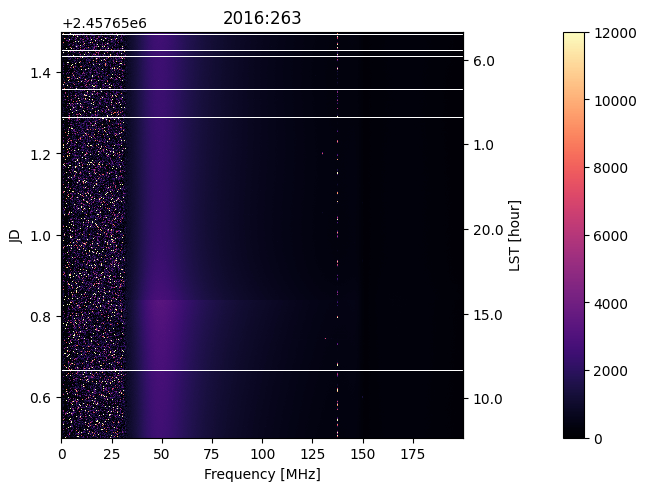

In [31]:
plots.plot_waterfall(data, vmin= 0, vmax=1.2e4);

### More Integration Filters

In [32]:
if do_peak_orbcomm_filter:
    data = filters.peak_orbcomm_filter(
        data,
        **peak_orbcomm_params
    )
    print(f"{data.flags['peak_orbcomm_filter'].flags.sum()}/{data.ntimes} integrations flagged by peak_orbcomm_filter ({data.complete_flags[0, 0, :, 0].sum()} overall)")

0/1135 integrations flagged by peak_orbcomm_filter (17 overall)


In [33]:
# Check ppercent_flags against Alan
pkpower_flags_alan = time_flags_alan['pkpower'].astype(bool)[alan_gha_mask & aux_mask_alan]
assert np.sum(~data.flags['peak_orbcomm_filter'].flags[0,0,aux_mask_alan[alan_gha_mask]] ^ pkpower_flags_alan) == 0

In [34]:
if do_maxfm_filter:
    data = filters.maxfm_filter(
        data,
        **maxfm_filter_params
    )
    print(f"{data.flags['maxfm_filter'].flags.sum()}/{data.ntimes} integrations flagged by maxfm_filter ({data.complete_flags[0, 0, :, 0].sum()} overall)")

53/1135 integrations flagged by maxfm_filter (70 overall)


In [35]:
# Check ppercent_flags against Alan
maxfm_flags_alan = time_flags_alan['fmpwr'].astype(bool)[alan_gha_mask & aux_mask_alan]
assert np.sum(~data.flags['maxfm_filter'].flags[0,0,aux_mask_alan[alan_gha_mask]] ^ maxfm_flags_alan) == 0

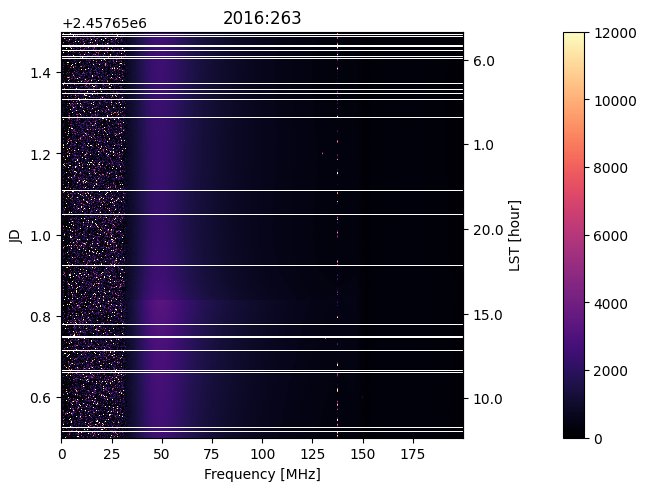

In [36]:
plots.plot_waterfall(data, vmin= 0, vmax=1.2e4);

In [37]:
# Final check that all our flags are accurate
full_alan_time_flags = np.all(np.array([time_flags_alan[name].astype(bool) for name in time_flags_alan.dtype.names]), axis=0)
assert np.sum(~data.complete_flags[0,0,:, 0] ^ full_alan_time_flags[alan_gha_mask]) == 0

### Average Over LSTs

In [38]:
lstbin_data = lst_bin(data, **lstbin_params)

/data4/smurray/edges/edges-analysis/src/edges_analysis/averaging/averaging.py:573: RuntimeWarning: invalid value encountered in multiply
  sm = np.nansum(data * weights, axis=axis)
/data4/smurray/edges/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


/data4/smurray/edges/pygsdata/src/pygsdata/register.py:25: UserWarning: Auxiliary measurements cannot being binned!
  newdata = self.func(data, *args, **kw)


In [39]:
data = select_freqs(lstbin_data, freq_range=[first_freqcut_min*un.MHz, first_freqcut_max*un.MHz])
pre_rfi_data = deepcopy(data)

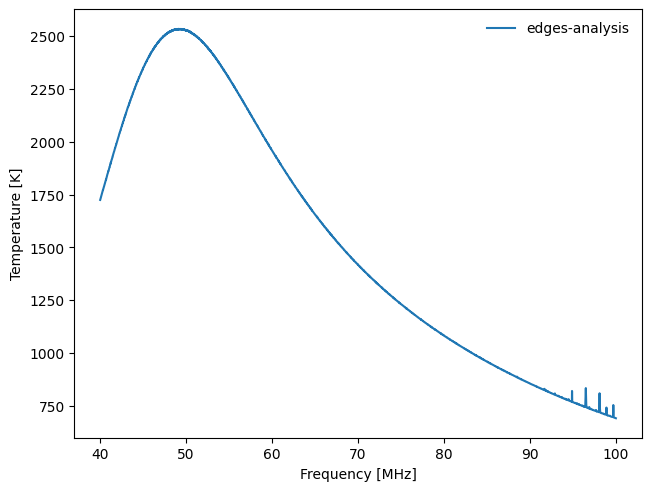

In [40]:
plot_single_spectrum(data)

## Single-LST-Bin Workflow

### RFI Excision

In [41]:
pre_rfi_file = (cache/ obsname).with_suffix('.pre-rfi.gsh5')
try:
    pre_rfi_data.write_gsh5(pre_rfi_file);
except NameError:
    pre_rfi_data = GSData.from_file(pre_rfi_file)

In [42]:
alan_rfi_flags = ~np.genfromtxt(alan_output_dir/"rfi_flags.txt").astype(bool)

In [43]:
if inject_flags:
    rfiflg = GSFlag(alan_rfi_flags[-1], axes=('freq',))
    data = pre_rfi_data.add_flags('injected-rfi', rfiflg, append_to_file=False)
else:
    data = filters.rfi_model_nonlinear_window_filter(
        pre_rfi_data,
        max_iter=100,
        model = mdl.Fourier(n_terms=37, period=1.5, transform=mdl.ZerotooneTransform(
            range=(
                data.freqs.min().to_value("MHz"), 
                data.freqs.max().to_value("MHz"),
            )
        )),
        fit_kwargs = {"method": 'alan-qrd'},
        window_frac = 16,
        min_window_size = 10,
        threshold = 2.5,
        reflag_thresh = 1.0,
        watershed = {
            1.0: 4,
            10.0: 8,
            100.0: 16
        }
    )

In [44]:
print(f"{data.complete_flags.sum()}/{data.nfreqs} channels flagged during xrfi")

1177/9831 channels flagged during xrfi


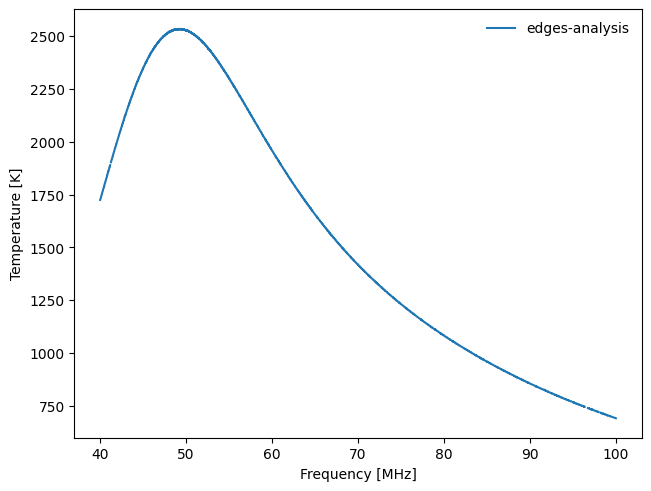

In [45]:
plot_single_spectrum(data)

### Smooth Over Frequency

In [46]:
pre_smooth_data = deepcopy(data)

In [47]:
data = gauss_smooth(data, **gauss_smooth_params)

In [48]:
# After smoothing, any flags over the frequency axis are removed, but nsamples is maintained correctly.
ourflags = data.nsamples[0,0,0] == 0

In [49]:
pre_cal_data = deepcopy(data)

In [50]:
alan_avg, n = read_spec_txt(alan_output_dir/"spegva.txt")

In [51]:
assert np.sum(~ourflags ^ (alan_avg['weight']>0))==0

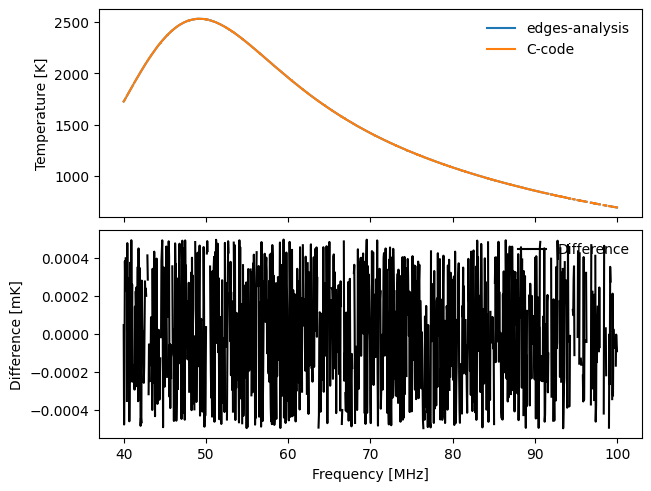

In [52]:
plot_single_spectrum(pre_cal_data, alan_avg['spectra'])

## Calibration Steps (`edges2k.c`)

### Noise-Wave Calibration

In [53]:
pre_cal_file = (cache/ obsname).with_suffix('.pre-cal.gsh5')
try:
    pre_cal_data.write_gsh5(pre_cal_file);
except NameError:
    pre_cal_data = GSData.from_file(pre_cal_file)

In [54]:
data = select_freqs(pre_cal_data, freq_range=(50, 100))

frequency range given without units, assuming MHz.


In [55]:
data = filters.flag_frequency_ranges(data, freq_ranges=((51, 99),), invert=True)

In [56]:
alan_pre_cal = np.genfromtxt(alan_output_dir/"spectra_before_noise_waves.txt")

In [57]:
data = apply_noise_wave_calibration(
    data,
    calobs = calobs,
    band='low',
    ant_s11_object="outputs/2015_ants11_modelled_redone.h5",
)

In [58]:
alan_spec_after_nw = np.genfromtxt(alan_output_dir/"spectra_after_noise_waves.txt", names=True)

In [59]:
alan_ants11 = np.genfromtxt(alan_output_dir/"modeled_antenna_s11.txt")

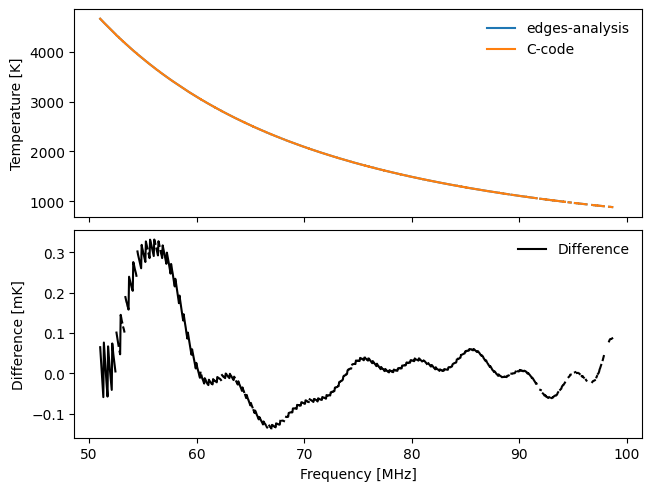

In [60]:
plot_single_spectrum(data, alan_spec_after_nw['spec'])

### Loss-Correction

In [61]:
# Apply different loss corrections
data = apply_loss_correction(data, ants11="outputs/2015_ants11_modelled_redone.h5", ambient_temp=296*un.K, loss_function=low2_balun_connector_loss, use_approx_eps0=True)
# no antenna correction
# no ground loss

In [62]:
alan_spec_after_loss = np.genfromtxt(alan_output_dir / "spectra_after_loss.txt", names=True)

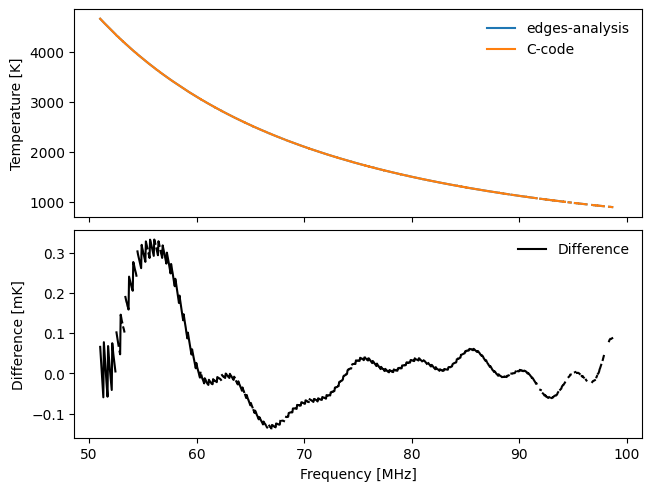

In [63]:
plot_single_spectrum(data, alan_spec_after_loss['spec'])

### Beam Correction

In [64]:
pre_beam_data = data

In [65]:
if do_beam_correction:
    data = apply_beam_correction(
        pre_beam_data, 
        beam="/data4/nmahesh/edges/edges-field-levels/beam_factors/alan_newfc.h5",
        freq_model = mdl.Fourier(n_terms=31, transform=mdl.ShiftTransform(shift=75.0), period=72.0),
        resample_beam_lsts = False,
        integrate_before_ratio = True,
    )
else:
    data = pre_beam_data

In [66]:
# Get Alan's file after beam correction. NOTE: if beam correction is turned off in the script running the C-code, then this
# will NOT have beam correction actually applied, and will be the same as the previous plot.
alan_after_beam = np.genfromtxt(alan_output_dir/"spectra_after_beam.txt", names=True)

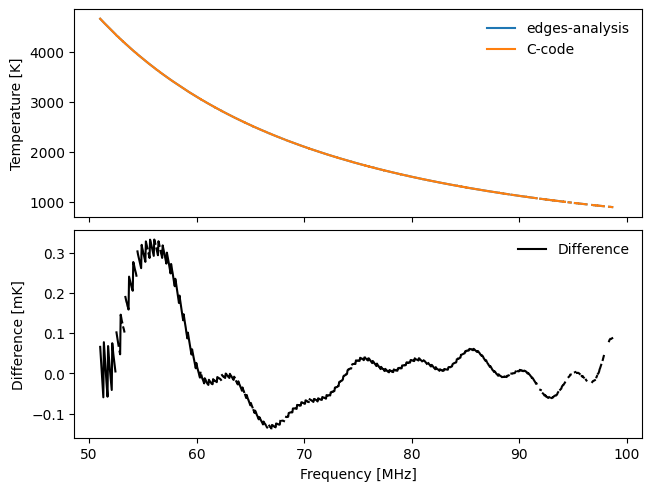

In [67]:
plot_single_spectrum(data, alan_after_beam['spec'])

### Smooth Over Frequencies Again

In [68]:
data = add_model(data, model=mdl.PhysicalLin(n_terms=3, spectral_index=-2.5, f_center=75.0, with_cmb=False), nsamples_strategy='flagged-nsamples-uniform')

In [69]:
alan_mdl = np.genfromtxt(alan_output_dir /"second_smooth_input.txt", names=True)

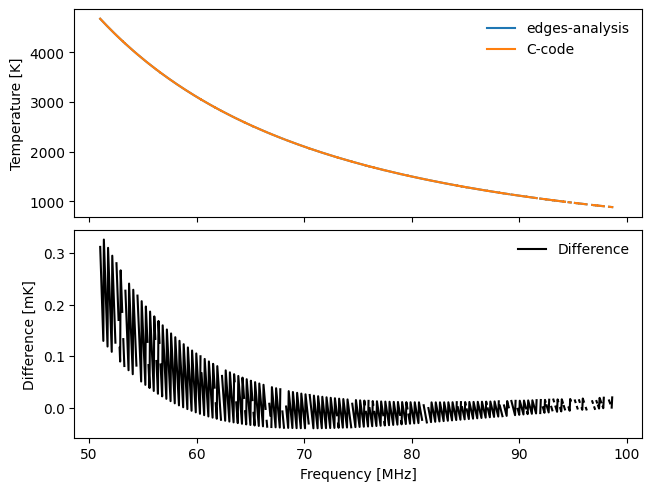

In [70]:
plot_single_spectrum(data, alan_mdl['model'], attribute='model')

In [71]:
data = gauss_smooth(data, size=8, nsmooth=2, decimate_at=0, maintain_flags=9, use_residuals=True, use_nsamples=False)

In [72]:
alan_specavg = np.genfromtxt(alan_output_dir / "specavg_cal.txt", usecols=(1,3,9))

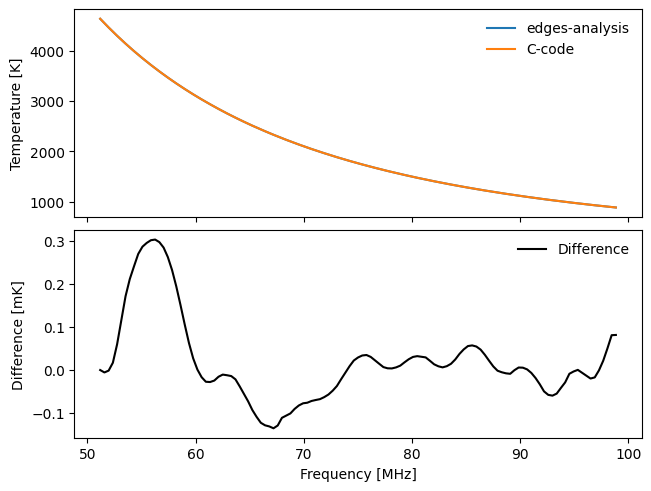

In [73]:
plot_single_spectrum(data, alan_specavg[:, 1])